In [ ]:
#troubleshooting matplotlib, this took half an hour

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)

1.26.4
2.1.3
3.8.0


# Week 4 Data Exploration Challenge

## Welltory COVID-19 and Wearables Open Data Research

This notebook explores the structure and quality of the Welltory COVID-19 and
Wearables dataset, with a focused analysis of heart rate variability (HRV) and
participant characteristics.

The source data contains multiple tables collected at different levels of
granularity, including participant records, repeated physiological measurements,
wearable observations, sleep data, surveys, and weather data. I first profile
the full dataset to understand its sampling and quality before focusing on HRV,
which has the broadest participant coverage.

In [4]:
import sys
print(sys.executable)

from pathlib import Path
#Get the dataset into the notbook
DATA_DIR = Path("../data/week4/welltory")

files = list(DATA_DIR.rglob("*"))

for f in files:
    if f.is_file():
        print(f.relative_to(DATA_DIR))

/Users/arshaansayed/aipi510-fall26/.venv/bin/python
scales_description.csv
LICENSE
participants.csv
datatypes.md
wearables.csv
blood_pressure.csv
surveys.csv
SOURCE_README.md
heart_rate.csv
weather.csv
hrv_measurements.csv
sleep.csv


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("../data/week4/welltory")

In [6]:
#what are all the files we have available?

csv_files = sorted(DATA_DIR.glob("*.csv"))

for file in csv_files:
    print(file.name)

blood_pressure.csv
heart_rate.csv
hrv_measurements.csv
participants.csv
scales_description.csv
sleep.csv
surveys.csv
wearables.csv
weather.csv


In [7]:
#load the datasets into a dictionary for easy access

datasets = {}

for file in csv_files:
    datasets[file.stem] = pd.read_csv(file)

print(f"Loaded {len(datasets)} datasets.")

Loaded 9 datasets.


In [8]:
datasets.keys()

dict_keys(['blood_pressure', 'heart_rate', 'hrv_measurements', 'participants', 'scales_description', 'sleep', 'surveys', 'wearables', 'weather'])

## 1. Dataset Inventory

The Welltory research data is distributed across multiple tables. Before
combining or transforming them, I first examine the dimensions and basic
quality characteristics of each table.

This is important because the tables may represent different levels of
observation, such as one row per participant versus many measurements per
participant.

In [9]:
#First level inspection of datasets 

overview = []

for name, df in datasets.items():
    overview.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_cells": df.isna().sum().sum(),
        "duplicate_rows": df.duplicated().sum()
    })

overview_df = pd.DataFrame(overview)

overview_df

,dataset,rows,columns,missing_cells,duplicate_rows
0,blood_pressure,721,8,1704,0
1,heart_rate,523783,4,0,0
2,hrv_measurements,3245,22,2823,0
3,participants,185,8,58,0
4,scales_description,148,4,0,0
5,sleep,425,12,2873,0
6,surveys,2259,5,0,0
7,wearables,3098,18,26887,0
8,weather,1717,7,0,0


In [10]:
#gauge the datasets' first few rows to get a sense of the data

for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)
    display(df.head())


BLOOD_PRESSURE


,user_code,measurement_datetime,diastolic,systolic,functional_changes_index,circulatory_efficiency,kerdo_vegetation_index,robinson_index
0,01bad5a519,2020-04-29 22:33:33,100,150,NaN,NaN,NaN,NaN
1,01bad5a519,2020-04-30 01:33:33,100,150,NaN,NaN,NaN,NaN
2,01bad5a519,2020-04-30 09:16:38,95,140,3.38,4545.0,6.0,141.4
3,01bad5a519,2020-04-30 12:16:38,95,140,NaN,NaN,NaN,NaN
4,01bad5a519,2020-05-01 06:58:06,80,130,2.89,4000.0,NaN,104.0



HEART_RATE


,user_code,datetime,heart_rate,is_resting
0,007b8190cf,2020-04-26 04:49:25,70,0
1,01bad5a519,2020-04-23 06:21:03,74,0
2,01bad5a519,2020-04-23 09:46:01,82,0
3,01bad5a519,2020-04-23 14:05:06,90,0
4,01bad5a519,2020-04-24 03:41:18,72,0



HRV_MEASUREMENTS


...

,user_code,scale,created_at,value,text
0,01bad5a519,S_CORONA,2020-04-23,2,Symptoms are characteristic of coronavirus
1,01bad5a519,S_COVID_BLUISH,2020-04-23,1,User isn’t experiencing symptom
2,01bad5a519,S_COVID_BLUISH,2020-04-25,1,User isn’t experiencing symptom
3,01bad5a519,S_COVID_BLUISH,2020-04-27,1,User isn’t experiencing symptom
4,01bad5a519,S_COVID_BLUISH,2020-04-29,1,User isn’t experiencing symptom



WEARABLES


,user_code,day,resting_pulse,pulse_average,pulse_min,pulse_max,average_spo2_value,body_temperature_avg,stand_hours_total,steps_count,distance,steps_speed,total_number_of_flights_climbed,active_calories_burned,basal_calories_burned,total_calories_burned,average_headphone_exposure,average_environment_exposure
0,007b8190cf,2020-04-26,NaN,70.0,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2859.0,2859.0,NaN,NaN
1,01bad5a519,2020-02-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8574.0,NaN,57.90,NaN,NaN,2624.0,2624.0,NaN,NaN
2,01bad5a519,2020-02-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7462.0,NaN,59.10,NaN,NaN,2624.0,2624.0,NaN,NaN
3,01bad5a519,2020-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2507.0,NaN,60.97,NaN,NaN,2624.0,2624.0,NaN,NaN
4,01bad5a519,2020-02-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10131.0,NaN,49.10,NaN,NaN,2624.0,2624.0,NaN,NaN



WEATHER


,user_code,day,avg_temperature_C,atmospheric_pressure,precip_intensity,humidity,clouds
0,013f6d3e5b,2020-05-22,18.0667,1017.6,0.0002,70.0,67.0
1,01bad5a519,2020-01-11,-1.2111,1016.4,0.0002,92.0,6.0
2,01bad5a519,2020-01-30,0.5056,1004.7,0.0009,85.0,100.0
3,01bad5a519,2020-04-02,-0.2444,994.4,0.0025,91.0,87.0
4,01bad5a519,2020-04-12,5.1778,1016.1,0.0000,61.0,91.0


In [11]:
#see all columns in each dataset

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.columns.tolist())


BLOOD_PRESSURE
['user_code', 'measurement_datetime', 'diastolic', 'systolic', 'functional_changes_index', 'circulatory_efficiency', 'kerdo_vegetation_index', 'robinson_index']

HEART_RATE
['user_code', 'datetime', 'heart_rate', 'is_resting']

HRV_MEASUREMENTS
['user_code', 'rr_code', 'measurement_datetime', 'time_of_day', 'bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood', 'how_sleep', 'tags', 'rr_data']

PARTICIPANTS
['user_code', 'gender', 'age_range', 'city', 'country', 'height', 'weight', 'symptoms_onset']

SCALES_DESCRIPTION
['Scale', 'Description', 'Value', 'Meaning']

SLEEP
['user_code', 'day', 'sleep_begin', 'sleep_end', 'sleep_duration', 'sleep_awake_duration', 'sleep_rem_duration', 'sleep_light_duration', 'sleep_deep_duration', 'pulse_min', 'pulse_max', 'pulse_average']

SURVEYS
['user_code', 'scale', 'created_at', 'value', 'text']

WEARABLES
['user_code', 'day', 'resting_pulse', 'pulse_average'

In [12]:
#gather more info on how clean each dataset is, including data types, missing values, and unique values

for name, df in datasets.items():

    profile = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=False)
    })

    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    display(profile)


BLOOD_PRESSURE


,dtype,non_null,missing,missing_pct,unique_values
user_code,object,721,0,0.00,28
measurement_datetime,object,721,0,0.00,719
diastolic,int64,721,0,0.00,45
systolic,int64,721,0,0.00,55
functional_changes_index,float64,299,422,58.53,111
circulatory_efficiency,float64,299,422,58.53,231
kerdo_vegetation_index,float64,283,438,60.75,78
robinson_index,float64,299,422,58.53,254



HEART_RATE


,dtype,non_null,missing,missing_pct,unique_values
user_code,object,523783,0,0.0,79
datetime,object,523783,0,0.0,506422
heart_rate,int64,523783,0,0.0,194
is_resting,int64,523783,0,0.0,2



HRV_MEASUREMENTS


...

,dtype,non_null,missing,missing_pct,unique_values
user_code,object,2259,0,0.0,111
scale,object,2259,0,0.0,58
created_at,object,2259,0,0.0,50
value,int64,2259,0,0.0,6
text,object,2259,0,0.0,65



WEARABLES


,dtype,non_null,missing,missing_pct,unique_values
user_code,object,3098,0,0.00,79
day,object,3098,0,0.00,171
resting_pulse,float64,1515,1583,51.10,67
pulse_average,float64,2089,1009,32.57,86
pulse_min,float64,2089,1009,32.57,84
pulse_max,float64,2089,1009,32.57,145
average_spo2_value,float64,40,3058,98.71,9
body_temperature_avg,float64,65,3033,97.90,21
stand_hours_total,float64,531,2567,82.86,20
steps_count,float64,1968,1130,36.48,1780



WEATHER


,dtype,non_null,missing,missing_pct,unique_values
user_code,object,1717,0,0.0,104
day,object,1717,0,0.0,169
avg_temperature_C,float64,1717,0,0.0,1523
atmospheric_pressure,float64,1717,0,0.0,635
precip_intensity,float64,1717,0,0.0,205
humidity,float64,1717,0,0.0,288
clouds,float64,1717,0,0.0,327


In [13]:
for name, df in datasets.items():

    numeric = df.select_dtypes(include=np.number)

    if not numeric.empty:

        print("\n" + "=" * 70)
        print(f"{name.upper()} - NUMERICAL VARIABLES")
        print("=" * 70)

        display(numeric.describe().T)


BLOOD_PRESSURE - NUMERICAL VARIABLES


,count,mean,std,min,25%,50%,75%,max
diastolic,721.0,81.228849,8.865761,25.00,76.00,82.00,88.00,101.00
systolic,721.0,119.441054,10.522578,63.00,113.00,120.00,126.00,157.00
functional_changes_index,299.0,2.594013,0.291302,1.68,2.44,2.58,2.73,3.51
circulatory_efficiency,299.0,2735.197057,747.882570,1300.00,2250.50,2640.00,3076.50,7875.00
kerdo_vegetation_index,283.0,-15.498233,18.681233,-76.00,-29.00,-17.00,-5.00,45.00
robinson_index,299.0,84.663779,14.399208,49.50,75.58,83.22,93.17,164.85



HEART_RATE - NUMERICAL VARIABLES


,count,mean,std,min,25%,50%,75%,max
heart_rate,523783.0,90.856626,25.054152,10.0,71.0,87.0,108.0,232.0
is_resting,523783.0,0.005546,0.074266,0.0,0.0,0.0,0.0,1.0



HRV_MEASUREMENTS - NUMERICAL VARIABLES


...

,count,mean,std,min,25%,50%,75%,max
value,2259.0,2.364763,1.554934,1.0,1.0,2.0,4.0,6.0



WEARABLES - NUMERICAL VARIABLES


,count,mean,std,min,25%,50%,75%,max
resting_pulse,1515.0,61.409241,12.775324,40.00,52.0000,58.000,69.0000,109.00
pulse_average,2089.0,78.084251,14.366994,48.00,69.0000,76.000,85.0000,163.00
pulse_min,2089.0,63.078506,14.334455,10.00,53.0000,60.000,72.0000,122.00
pulse_max,2089.0,99.456199,29.298930,48.00,76.0000,96.000,118.0000,225.00
average_spo2_value,40.0,0.961000,0.021340,0.92,0.9475,0.960,0.9800,0.99
body_temperature_avg,65.0,36.404615,0.239394,35.80,36.2000,36.400,36.6000,36.90
stand_hours_total,531.0,8.986817,5.030643,1.00,4.0000,10.000,13.0000,19.00
steps_count,1968.0,5342.067581,4761.774987,1.00,1456.0000,4477.500,7857.2500,30882.00
distance,1869.0,3494.690744,3599.635544,1.00,772.0000,2687.000,5035.0000,43914.00
steps_speed,1418.0,29.700409,28.068371,0.01,10.4000,24.575,44.0975,240.00



WEATHER - NUMERICAL VARIABLES


,count,mean,std,min,25%,50%,75%,max
avg_temperature_C,1717.0,11.839221,7.769565,-13.15,6.4722,11.2722,16.6639,44.0722
atmospheric_pressure,1717.0,1014.111639,8.356792,984.30,1009.0000,1014.1000,1019.5667,1047.7500
precip_intensity,1717.0,0.003803,0.015348,0.00,0.0000,0.0002,0.0017,0.2567
humidity,1717.0,66.376586,19.339670,3.00,54.0000,68.0000,81.0000,100.0000
clouds,1717.0,56.401734,35.048917,0.00,24.5000,61.5000,91.0000,100.0000


## Data Context, Sampling, and Key Features

The dataset is longitudinal rather than a single cross-sectional table. The
`participants` table contains one row for each of 185 participants, while the
measurement tables contain repeated observations over time.

Coverage varies substantially across data sources. HRV measurements include all
185 participants and contain 3,245 observations. By comparison, heart-rate data
contains more than 500,000 observations but only 79 participants, sleep data
contains only 10 participants, and blood-pressure data contains 28 participants.
The number of observations per participant is also highly uneven. For HRV, the
median participant has 4 measurements while the maximum is 405.

Because of this uneven sampling, the number of rows should not be interpreted as
the number of independent participants. I therefore use the HRV table for the
focused analysis because it provides the most consistent participant coverage.

### Selected HRV Features

- `bpm`: heart rate in beats per minute during the HRV measurement.
- `meanrr`: average interval between successive heartbeats.
- `sdnn`: standard deviation of normal-to-normal heartbeat intervals, a measure
  of overall heart-rate variability.
- `rmssd`: root mean square of successive differences between heartbeat
  intervals, a commonly used measure of short-term HRV.
- `pnn50`: percentage of successive heartbeat intervals differing by more than
  50 ms.
- `lf`, `hf`, and `vlf`: frequency-domain components of HRV.
- `lfhf`: ratio of low-frequency to high-frequency power.
- `total_power`: overall spectral power across HRV frequency components.
- `time_of_day`: categorical period in which the measurement was recorded.
- `how_feel`, `how_mood`, and `how_sleep`: self-reported participant ratings
  associated with a measurement.

In [14]:
#each dataset has a user_code column, which is the unique identifier for each user. Let's see how many unique users are in each dataset.

for name, df in datasets.items():
    if "user_code" in df.columns:
        print(
            f"{name:20s} "
            f"rows={len(df):7,} | "
            f"unique users={df['user_code'].nunique():3}"
        )

blood_pressure       rows=    721 | unique users= 28
heart_rate           rows=523,783 | unique users= 79
hrv_measurements     rows=  3,245 | unique users=185
participants         rows=    185 | unique users=185
sleep                rows=    425 | unique users= 10
surveys              rows=  2,259 | unique users=111
wearables            rows=  3,098 | unique users= 79
weather              rows=  1,717 | unique users=104


In [15]:
#check for missing values in each dataset

for name, df in datasets.items():
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2)
    })

    missing = missing[missing["missing_count"] > 0]
    
    print(f"\n{name.upper()}")
    
    if len(missing) == 0:
        print("No missing values")
    else:
        display(missing.sort_values("missing_pct", ascending=False))


BLOOD_PRESSURE


,missing_count,missing_pct
kerdo_vegetation_index,438,60.75
functional_changes_index,422,58.53
circulatory_efficiency,422,58.53
robinson_index,422,58.53



HEART_RATE
No missing values

HRV_MEASUREMENTS


,missing_count,missing_pct
how_sleep,1779,54.82
tags,1044,32.17



PARTICIPANTS


...


SCALES_DESCRIPTION
No missing values

SLEEP


,missing_count,missing_pct
sleep_rem_duration,418,98.35
sleep_awake_duration,416,97.88
sleep_deep_duration,411,96.71
pulse_min,410,96.47
pulse_max,410,96.47
pulse_average,410,96.47
sleep_light_duration,398,93.65



SURVEYS
No missing values

WEARABLES


,missing_count,missing_pct
average_spo2_value,3058,98.71
body_temperature_avg,3033,97.90
average_environment_exposure,2949,95.19
average_headphone_exposure,2868,92.58
stand_hours_total,2567,82.86
active_calories_burned,1898,61.27
total_number_of_flights_climbed,1863,60.14
steps_speed,1680,54.23
resting_pulse,1583,51.10
distance,1229,39.67



WEATHER
No missing values


In [16]:
candidate_keys = {
    "participants": ["user_code"],
    "heart_rate": ["user_code", "datetime"],
    "blood_pressure": ["user_code", "measurement_datetime"],
    "hrv_measurements": ["user_code", "measurement_datetime"],
    "sleep": ["user_code", "day"],
    "wearables": ["user_code", "day"],
    "weather": ["user_code", "day"],
    "surveys": ["user_code", "scale", "created_at"],
    "scales_description": ["Scale", "Value"]
}

for name, keys in candidate_keys.items():
    df = datasets[name]

    duplicate_keys = df.duplicated(subset=keys).sum()

    print(
        f"{name:20s} "
        f"candidate key={keys} | "
        f"duplicate keys={duplicate_keys}"
    )

participants         candidate key=['user_code'] | duplicate keys=0


heart_rate           candidate key=['user_code', 'datetime'] | duplicate keys=7330
blood_pressure       candidate key=['user_code', 'measurement_datetime'] | duplicate keys=0
hrv_measurements     candidate key=['user_code', 'measurement_datetime'] | duplicate keys=0
sleep                candidate key=['user_code', 'day'] | duplicate keys=38
wearables            candidate key=['user_code', 'day'] | duplicate keys=0
weather              candidate key=['user_code', 'day'] | duplicate keys=0
surveys              candidate key=['user_code', 'scale', 'created_at'] | duplicate keys=24
scales_description   candidate key=['Scale', 'Value'] | duplicate keys=0


In [17]:
#what is the timeframe for each dataset? Let's convert the date columns to datetime objects and see the min and max dates.

date_columns = {
    "heart_rate": "datetime",
    "blood_pressure": "measurement_datetime",
    "hrv_measurements": "measurement_datetime",
    "sleep": "day",
    "wearables": "day",
    "weather": "day",
    "surveys": "created_at"
}

for name, col in date_columns.items():
    datasets[name][col] = pd.to_datetime(
        datasets[name][col],
        errors="coerce"
    )

for name, col in date_columns.items():
    df = datasets[name]

    print(
        f"{name:20s} "
        f"{df[col].min()}  →  {df[col].max()}"
    )

heart_rate           2020-01-01 00:00:00  →  2020-06-19 08:40:13
blood_pressure       2019-12-31 10:48:51  →  2020-06-19 10:48:05
hrv_measurements     2019-12-31 06:08:29  →  2020-06-19 11:40:13
sleep                2019-12-31 00:00:00  →  2020-06-17 00:00:00
wearables            2020-01-01 00:00:00  →  2020-06-19 00:00:00
weather              2020-01-01 00:00:00  →  2020-06-19 00:00:00
surveys              2020-01-15 00:00:00  →  2020-05-28 00:00:00


In [18]:
#quantify how many records each user has in each dataset. This will help us understand the distribution of data across users and identify any potential outliers or users with insufficient data.

for name, df in datasets.items():
    if "user_code" in df.columns:
        counts = df.groupby("user_code").size()

        print(f"\n{name.upper()}")
        print(counts.describe())


BLOOD_PRESSURE
count     28.000000
mean      25.750000
std       67.193267
min        1.000000
25%        2.000000
50%        3.000000
75%       10.750000
max      333.000000
dtype: float64

HEART_RATE
count        79.000000
mean       6630.164557
std       21395.412398
min           1.000000
25%           6.000000
50%          23.000000
75%         229.500000
max      143879.000000
dtype: float64

HRV_MEASUREMENTS
count    185.000000
mean      17.540541
std       45.790517
min        1.000000
25%        1.000000
50%        4.000000
75%       12.000000
max      405.000000
dtype: float64

PARTICIPANTS
count    185.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64

SLEEP
count     10.000000
mean      42.500000
std       41.293664
min        1.000000
25%        7.500000
50%       28.000000
75%       68.500000
max      108.000000
dtype: float64

SURVEYS
count    111.000000
mean      20.351351
std       26.152924
min  

## Focused Analysis: HRV and Participant Characteristics

I focus the remainder of the analysis on the participant and HRV tables. HRV is the only measurement table with coverage across all 185 participants, making it more suitable for cohort-level exploration than more sparsely sampled sources such as sleep or blood pressure.

In [19]:
participants = datasets["participants"].copy()
hrv = datasets["hrv_measurements"].copy()

participants["symptoms_onset"] = pd.to_datetime(
    participants["symptoms_onset"],
    errors="coerce"
)

hrv["measurement_datetime"] = pd.to_datetime(
    hrv["measurement_datetime"],
    errors="coerce"
)

hrv_analysis = hrv.merge(
    participants,
    on="user_code",
    how="left",
    validate="many_to_one"
)

print(hrv_analysis.shape)
display(hrv_analysis.head())

(3245, 29)


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,...,how_sleep,tags,rr_data,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,...,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8...",m,25-34,Mandalay,Myanmar,170.18,96.162,NaT
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,...,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83...",m,25-34,Mandalay,Myanmar,170.18,96.162,NaT
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,...,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73...",f,18-24,São Paulo,Brazil,174.00,77.300,2020-05-15
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,...,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75...",f,18-24,São Paulo,Brazil,174.00,77.300,2020-05-15
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,...,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76...",m,45-54,St Petersburg,Russia,178.00,92.000,2020-04-05


In [20]:
profile = pd.DataFrame({
    "dtype": hrv_analysis.dtypes.astype(str),
    "missing_count": hrv_analysis.isna().sum(),
    "missing_pct": (hrv_analysis.isna().mean() * 100).round(2),
    "unique_values": hrv_analysis.nunique(dropna=False)
})

display(profile)

,dtype,missing_count,missing_pct,unique_values
user_code,object,0,0.00,185
rr_code,object,0,0.00,3245
measurement_datetime,datetime64[ns],0,0.00,3241
time_of_day,object,0,0.00,4
bpm,int64,0,0.00,71
meanrr,float64,0,0.00,3134
mxdmn,float64,0,0.00,66
sdnn,float64,0,0.00,3180
rmssd,float64,0,0.00,3174
pnn50,float64,0,0.00,146


In [21]:
display(
    hrv_analysis[
        ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lf", "hf", "lfhf", "total_power"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
bpm,3245.0,73.257935,12.201088,44.000,65.000,72.000,81.000,125.000
meanrr,3245.0,839.600366,137.420367,477.730,742.490,829.100,925.933,1346.740
sdnn,3245.0,52.489218,29.369506,9.515,32.585,46.919,64.406,206.631
rmssd,3245.0,52.814196,39.353213,6.340,28.985,42.869,62.485,310.800
pnn50,3245.0,20.615609,18.588156,0.000,6.060,16.160,29.290,91.920
lf,3245.0,927.038213,1455.424089,2.000,151.000,423.000,1059.000,15522.000
hf,3245.0,1125.041294,2490.540413,4.000,158.000,380.000,993.000,33490.000
lfhf,3245.0,2.397769,5.750760,0.032,0.399,0.862,1.966,105.625
total_power,3245.0,2630.309399,3912.247496,44.000,620.000,1387.000,2906.000,41118.000


### Missing Values

Missing values are not automatically imputed. Some HRV and self-reported fields may be absent because a measurement or subjective response was not collected. Replacing these values with means or medians could create artificial observations.

For analyses involving a particular variable, I therefore use the available observations for that variable rather than imputing missing values.

In [22]:
(
    hrv_analysis.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(10)
)

how_sleep         54.822804
tags              32.172573
symptoms_onset    13.220339
city               0.554700
height             0.246533
country            0.246533
lfhf               0.000000
weight             0.000000
age_range          0.000000
gender             0.000000
dtype: float64

In [23]:
print("Fully duplicated rows:", hrv_analysis.duplicated().sum())

print(
    "Duplicate user + timestamp combinations:",
    hrv_analysis.duplicated(
        subset=["user_code", "measurement_datetime"]
    ).sum()
)

Fully duplicated rows: 0
Duplicate user + timestamp combinations: 0


### Duplicates and Integrity

No fully duplicated HRV records were identified. I also checked the combination of participant and measurement timestamp to evaluate whether measurements that should represent distinct observations were repeated. I avoid removing records solely because physiological values are identical, since repeated physiological measurements can legitimately have the same value.

In [24]:
q1 = hrv_analysis["rmssd"].quantile(0.25)
q3 = hrv_analysis["rmssd"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

hrv_analysis["rmssd_outlier"] = (
    (hrv_analysis["rmssd"] < lower_bound) |
    (hrv_analysis["rmssd"] > upper_bound)
)

print("RMSSD bounds:", lower_bound, upper_bound)
print(hrv_analysis["rmssd_outlier"].value_counts())

RMSSD bounds: -21.265 112.735
rmssd_outlier
False    3050
True      195
Name: count, dtype: int64


### Descriptive Statistics

The HRV variables differ substantially in their distributions. BPM is relatively
compact, with a median of 72 beats per minute. RMSSD has a median of 42.87 but a
mean of 52.81 and a maximum of 310.8, suggesting a right-skewed distribution.

The frequency-domain variables are even more strongly skewed. For example,
median total power is 1,387 while the maximum exceeds 41,000. These differences
between medians, means, and maxima suggest that robust summaries such as medians
and IQRs are more informative than means alone for several HRV variables.

### Outliers

I used the IQR method to identify unusually high or low RMSSD measurements. I flag these observations rather than automatically removing them because extreme physiological measurements may represent either sensor artifacts or genuine biological variation. Without additional validation information, deletion would risk removing legitimate observations.

In [25]:
hrv_analysis["days_from_symptom_onset"] = (
    hrv_analysis["measurement_datetime"].dt.normalize()
    - hrv_analysis["symptoms_onset"]
).dt.days

In [26]:
def symptom_phase(days):
    if pd.isna(days):
        return "Unknown"
    elif days < 0:
        return "Before onset"
    elif days <= 7:
        return "0-7 days"
    elif days <= 14:
        return "8-14 days"
    else:
        return "15+ days"

hrv_analysis["symptom_phase"] = (
    hrv_analysis["days_from_symptom_onset"]
    .apply(symptom_phase)
)

hrv_analysis["symptom_phase"].value_counts()

symptom_phase
15+ days        1669
Before onset     732
Unknown          429
8-14 days        267
0-7 days         148
Name: count, dtype: int64

### Feature Engineering

I created `days_from_symptom_onset` by calculating the number of days between each HRV measurement and the participant's reported symptom-onset date.

I then grouped this into a categorical `symptom_phase` feature so HRV patterns can be compared before symptom onset, during the first week, during the second week, and later in the illness timeline.

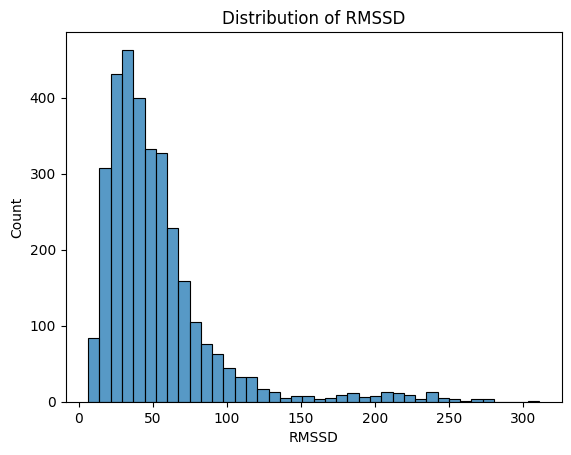

In [28]:
import seaborn as sns

sns.histplot(
    data=hrv_analysis,
    x="rmssd",
    bins=40
)

plt.title("Distribution of RMSSD")
plt.xlabel("RMSSD")
plt.show()

RMSSD is strongly right-skewed, with most measurements concentrated at lower values and a relatively small number of very high measurements. This supports using medians and IQR-based outlier assessment rather than relying only on the mean.

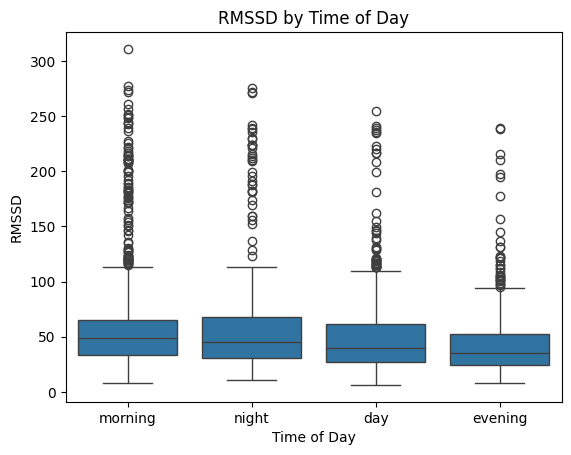

In [29]:
sns.boxplot(
    data=hrv_analysis,
    x="time_of_day",
    y="rmssd"
)

plt.title("RMSSD by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("RMSSD")
plt.show()

### HRV and Time of Day

RMSSD shows some variation across time-of-day groups. Morning measurements have
a somewhat higher median RMSSD, while evening measurements have the lowest
median in this sample. Night and daytime measurements fall between them.

However, the distributions overlap substantially and each group contains
high-value outliers. The visualization therefore suggests a descriptive
time-of-day pattern, but it does not by itself establish that time of day causes
differences in HRV.

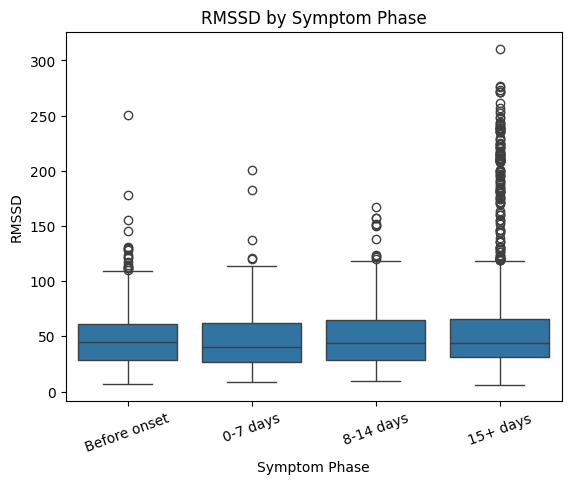

In [30]:
phase_order = [
    "Before onset",
    "0-7 days",
    "8-14 days",
    "15+ days"
]

sns.boxplot(
    data=hrv_analysis[
        hrv_analysis["symptom_phase"] != "Unknown"
    ],
    x="symptom_phase",
    y="rmssd",
    order=phase_order
)

plt.title("RMSSD by Symptom Phase")
plt.xlabel("Symptom Phase")
plt.ylabel("RMSSD")
plt.xticks(rotation=20)
plt.show()

## Data Quality Assessment

### Completeness

Data completeness varies substantially across the source tables. HRV provides
measurements for all 185 participants, while several other sources represent
only subsets of the cohort. Within the focused HRV analysis, the core
physiological measurements are complete, but `how_sleep`, tags, symptom-onset
dates, and several participant attributes contain missing values.

I do not automatically impute these values because their absence may reflect
data that was not collected rather than randomly missing measurements.
Analysis involving these fields therefore uses available observations.

### Accuracy and Outliers

RMSSD is strongly right-skewed. Using the IQR rule identified 195 observations
as potential outliers. I retain and flag these observations instead of deleting
them because unusually high HRV measurements could represent either genuine
physiological variation or measurement artifacts, and the dataset does not
provide sufficient information to distinguish between them.

### Consistency and Integrity

The source tables have different units of observation. Participant data is
one row per participant, while HRV and other physiological tables contain
repeated measurements. The HRV-to-participant merge was therefore performed as
a validated many-to-one relationship using `user_code`.

No fully duplicated HRV records were found, and no duplicate
participant-plus-measurement-time combinations were found in the focused HRV
dataset.

### Lineage and Provenance

The data comes from the Welltory COVID-19 and Wearables Open Data Research
repository. The original source files were retained locally without modifying
them. Cleaning, datetime conversion, merging, outlier flagging, and feature
engineering were performed in this notebook, preserving a reproducible path
from the source data to the analysis.

## Conclusion

The initial profiling shows that this is a longitudinal, unevenly sampled
wearable-health dataset rather than a uniformly collected cohort dataset.
HRV was selected for focused analysis because it covers all 185 participants.

RMSSD is strongly right-skewed and contains a meaningful upper tail, making
median-based summaries and explicit outlier handling appropriate. RMSSD also
shows modest descriptive differences across time of day, while distributions
across symptom phases overlap substantially.

Finally, creating `days_from_symptom_onset` and `symptom_phase` demonstrates how
raw dates can be transformed into analytically useful features while preserving
the original measurements.